In [9]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask


print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907739, 38.150835)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907722, 38.151140)
x0 =  4246866.863321021
y0 =  546964.9960692101
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907036, 38.149684)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  4246989.3147608945
y0 =  546674.5010509877
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908725, 38.157014)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907594, 38.151076)
x0 =  4247044.974506292
y0 =  547177.2816059613
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908

In [29]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))

rows = []  # collect per-date stats here

#ethiopia
startDate = "2021-10-01" #renaud  start date
startDate = "2021-09-30" # Works for Borana University site, in terms of Sentinel2 overflight dates


endDate = "2022-06-30" # Renaud end date
boranaLat0=4.908058823095451
boranaLon0= 38.15135412942004
#endDate = "2022-02-28" # temp


dates = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 1)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
print ("*****  boranaLat0, boranaLon0 : ",boranaLat0, boranaLon0)
precip_df = Utils.daily_precip_openmeteo(boranaLat0, boranaLon0, startDate, endDate)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df.head()
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
                                 
#dates = Utils.generate_date_range("2025-06-16", "2025-06-17",  "%Y-%m-%d", 5)

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(boranaLat0, boranaLon0),date, "rgb.uint8","tif")

    gdf_box = ConstantObjects.gdf_box_terreno_casa

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(boranaLat0, boranaLon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(boranaLat0, boranaLon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(boranaLat0, boranaLon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(boranaLat0, boranaLon0),date, "rgb-terreno-casa","tif")


    
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa)/3 
    #SCF continue here..
    cloudy =0
    if (red_green_blue_average) > 1650:  cloudy = 1

    #stats_terreno_casa = {
    #    "count_valid": 0,
    #    "mean": float("nan"),
    #    "median": float("nan"),
    #}
    #stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    #print("Avg NDMI over AOI plots 4,5:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)

    
    rows.append({
        "date": date,
     
        
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907739, 38.150835)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907722, 38.151140)
x0 =  4246866.863321021
y0 =  546964.9960692101
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907036, 38.149684)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  4246989.3147608945
y0 =  546674.5010509877
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908725, 38.157014)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907594, 38.151076)
x0 =  4247044.974506292
y0 =  547177.2816059613
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908

[Line 32] ...   
*****  boranaLat0, boranaLon0 :  4.908058823095451 38.15135412942004
[Line 1301] ...   
[Line 1306] ...   
[Line 1309] ... pd.to_datetime(d[time])   DatetimeIndex(['2021-09-30', '2021-10-01', '2021-10-02', '2021-10-03',
               '2021-10-04', '2021-10-05', '2021-10-06', '2021-10-07',
               '2021-10-08', '2021-10-09',
               ...
               '2022-06-21', '2022-06-22', '2022-06-23', '2022-06-24',
               '2022-06-25', '2022-06-26', '2022-06-27', '2022-06-28',
               '2022-06-29', '2022-06-30'],
              dtype='datetime64[ns]', length=274, freq=None)
[Line 1310] ... d[precipitation_sum]   [0.6, 1.0, 0.0, 4.4, 4.5, 18.4, 0.0, 1.1, 1.1, 0.7, 0.7, 0.3, 4.7, 0.6, 0.4, 0.1, 0.3, 0.7, 0.4, 1.9, 3.1, 1.4, 0.6, 1.3, 0.0, 3.0, 1.0, 1.4, 2.0, 1.6, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.5, 2.8, 1.7, 5.7, 1.1, 0.0, 0.1, 1.7, 1.2, 0.9, 0.4, 2.0, 1.5, 0.1, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 3.1, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [27]:
# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)


df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# --- existing: daily precip
precip_df = Utils.daily_precip_openmeteo(boranaLat0, boranaLon0, startDate, endDate)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

temp_df = Utils.daily_temp_openmeteo(boranaLat0, boranaLon0, startDate, endDate)
t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
#t["date"] = pd.to_datetime(t["date"]).dt.normalize()
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#p = p.sort_values("date")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)
# or
# out.to_excel("daily_table.xlsx", index=False)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 4] .. df =            date          red        green         blue  red_green_blue_average  \
0   2021-09-30  2536.326923  2451.006410  2605.448718             2479.446581   
1   2021-10-05  1493.121795  1398.775641  1472.282051             1430.224359   
2   2021-10-10  1647.807692  1680.032051  1877.307692             1669.290598   
3   2021-10-15   579.282051   506.044872   533.301282              530.457265   
4   2021-10-20  2012.397436  1926.660256  2017.506410             1955.239316   
5   2021-10-25   685.256410   642.775641   729.493590              656.935897   
6   2021-10-30   455.410256   476.698718   634.852564              469.602564   
7   2021-11-04   484.358974   510.826923   695.878205              502.004274   
8   2021-11-09  2232.641026  2120.801282  2192.371795             2158.081197   
9   2021-11-14   495.897436   501.615385   672.929487              499.709402   
10  2021-11-19   452.243590   478.525641   670.423077              469.764957   
11  2

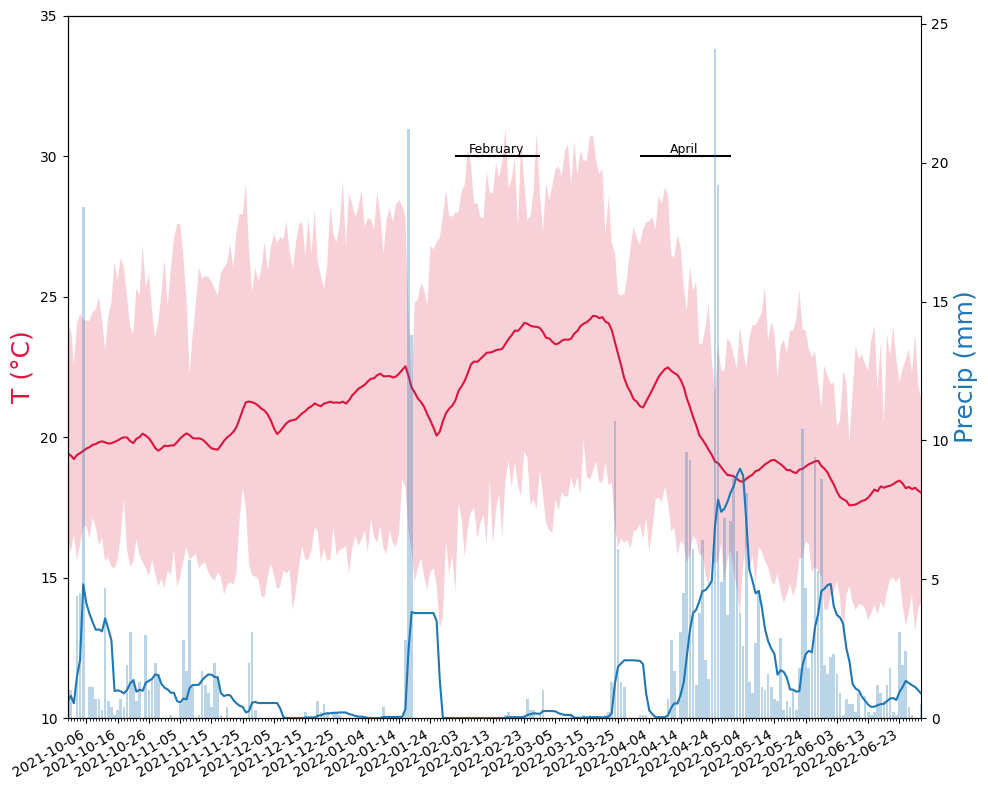

In [31]:
import matplotlib
import MatPlotLibUtils
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#importlib.reload(MatPlotLibUtils)
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(matplotlib)

import pandas

#warmDryStart2025 = pandas.to_datetime("2025-03-15")
#warmDryEnd2025   = pandas.to_datetime("2025-05-18") 
display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, ax = plt.subplots(figsize=(10, 8))
#ax=axes


minTemp = 10
maxTemp = 35
myfontsize = 18
# got rid of cloud cover, since it is only sampled every five days, and some days the image is incomplete. So could be a bit deceptive.
ax.bar(df["date"], df["cloudy"].fillna(0)*maxTemp,color="lightgrey",
        width=pd.Timedelta("5D"), alpha=0.3, label="Cloudy")
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
p["tave_30d"] = p["tavg"].rolling(window=30, min_periods=1).mean()

ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
#ax.plot(p["date"], p["tmax"],color=temperature_color, lw=1.5, label="T max (°C)") # takes min,max, avg
#ax.plot(p["date"], p["tmin"],color=temperature_color, lw=1.5, label="T min (°C)") # takes min,max, avg
pal = [ "#ffffff",temperature_color]
ax.stackplot(p["date"], [p["tmin"], p["tmax"]- p["tmin"]], colors = pal,  alpha=0.2)

ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
# Precip (second right axis; ALL daily bars)
ax2.bar(p["date"], p["precip_mm"].fillna(0),
        width=pd.Timedelta("0.85D"), alpha=0.3,  label="Precip (mm)",color=precip_color)

p["precip_mm_10d"] = p["precip_mm"].rolling(window=10, min_periods=1).mean()
ax2.plot(p["date"], p["precip_mm_10d"],color=precip_color, lw=1.5, label="Precipitation, 30-day back-average (mm)") 

#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)



# horizontal line
#start = pd.to_datetime("2024-03-01")
#end   = pd.to_datetime("2024-05-31")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
ax.set_xlim(xmin, xmax)

ax.hlines(y=30  , xmin=pd.to_datetime("2022-04-01"), xmax=pd.to_datetime("2022-04-30"), color="black")
#ax.vlines(y  , xmin=pd.to_datetime("2022-04-01"), xmax=pd.to_datetime("2022-04-30"), color="black")
# put label slightly above the line
ax.text(pd.to_datetime("2022-04-15"),30 , "April", ha="center", va="bottom", fontsize=9)

ax.hlines(y=30  , xmin=pd.to_datetime("2022-02-01"), xmax=pd.to_datetime("2022-02-28"), color="black")
#ax.vlines(y  , xmin=pd.to_datetime("2022-04-01"), xmax=pd.to_datetime("2022-04-30"), color="black")
# put label slightly above the line
ax.text(pd.to_datetime("2022-02-14"),30 , "February", ha="center", va="bottom", fontsize=9)

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))   # tick every 5 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("temp_precipitation_plot.png", dpi=300, bbox_inches="tight")